In [112]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [113]:
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [114]:
df = pd.read_csv("../data/raw_market/EURUSD_H1_20200101_20260131.csv", parse_dates=["time"])
df.set_index("time", inplace=True)
df.drop(columns=["spread", "real_volume"], inplace=True)

df

,open,high,low,close,tick_volume
time,,,,,
2020-01-01 22:00:00+00:00,1.12119,1.12159,1.12081,1.12147,414
2020-01-01 23:00:00+00:00,1.12147,1.12220,1.12146,1.12188,755
2020-01-02 00:00:00+00:00,1.12188,1.12192,1.12156,1.12183,704
2020-01-02 01:00:00+00:00,1.12183,1.12245,1.12181,1.12210,1000
2020-01-02 02:00:00+00:00,1.12209,1.12246,1.12184,1.12224,737
...,...,...,...,...,...
2026-01-30 17:00:00+00:00,1.18860,1.18875,1.18666,1.18724,5214
2026-01-30 18:00:00+00:00,1.18723,1.18843,1.18546,1.18784,6382
2026-01-30 19:00:00+00:00,1.18783,1.18850,1.18645,1.18694,4129


### Time Gaps Analysis

In [115]:
expected_freq = "1h"

time_deltas = df.index.to_series().diff()
expected_delta = pd.to_timedelta(expected_freq)

anomalous_gaps = time_deltas[(time_deltas > expected_delta) & (time_deltas < pd.Timedelta(days=2))]

print(f"Number of anomalous gaps: {len(anomalous_gaps)}")
anomalous_gaps

Number of anomalous gaps: 6


time
2020-09-30 21:00:00+00:00   0 days 02:00:00
2021-12-02 14:00:00+00:00   0 days 06:00:00
2024-12-25 22:00:00+00:00   1 days 01:00:00
2025-01-01 22:00:00+00:00   1 days 01:00:00
2025-12-25 22:00:00+00:00   1 days 01:00:00
2026-01-01 22:00:00+00:00   1 days 01:00:00
Name: time, dtype: timedelta64[us]

In [123]:
# Strip any existing dead hours recorded by the broker
df = df[df['tick_volume'] > 0]

# Forward-fill any internal NaNs just in case a price packet dropped but volume registered
df.ffill(inplace=True)

print(f"Zero volume rows: {len(df[df['tick_volume'] == 0])}")
print(f"Remaining NaNs: {df.isna().sum().sum()}")

Zero volume rows: 0
Remaining NaNs: 0


### Return Distribution

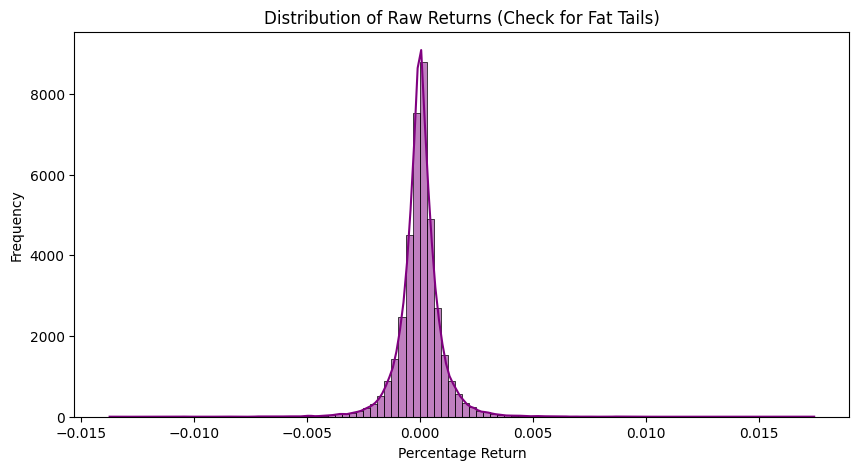

Skewness: 0.05 (0 is perfectly symmetrical)
Kurtosis: 15.55 (>3 indicates extreme outliers/fat tails)


In [117]:
returns = df['close'].pct_change().dropna()

plt.figure(figsize=(10, 5))
sns.histplot(x=returns, bins=100, kde=True, color='purple')
plt.title("Distribution of Raw Returns (Check for Fat Tails)")
plt.xlabel("Percentage Return")
plt.ylabel("Frequency")
plt.show()

# Kurtosis > 3 means fat tails. High kurtosis will blow up your MSE/Cross-Entropy gradients.
print(f"Skewness: {returns.skew():.2f} (0 is perfectly symmetrical)")
print(f"Kurtosis: {returns.kurtosis():.2f} (>3 indicates extreme outliers/fat tails)")

### Profile Tick Volume

C:\Users\kavin\AppData\Local\Temp\ipykernel_30504\1916390112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_volume.index, y=hourly_volume.values, palette='Blues_d')


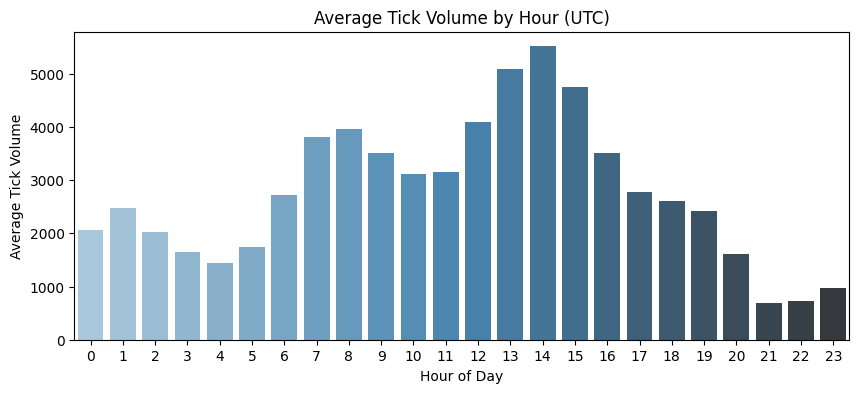

In [118]:
hourly_volume = df.groupby(df.index.hour)['tick_volume'].mean() # type: ignore

plt.figure(figsize=(10, 4))
sns.barplot(x=hourly_volume.index, y=hourly_volume.values, palette='Blues_d')
plt.title("Average Tick Volume by Hour (UTC)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Tick Volume")
plt.show()

In [119]:
plot_df = df.loc["2026-01-01":"2026-01-31"]

time_step = pd.Timedelta(plot_df.index.to_series().diff().median())
dynamic_dvalue = int(time_step.total_seconds() * 1000)

fig = go.Figure(data=[go.Candlestick(x=plot_df.index,
                open=plot_df["open"],
                high=plot_df["high"],
                low=plot_df["low"],
                close=plot_df["close"],
                name="Market Data")]
                )

fig.update_layout(
    title="EUR/USD Price Action",
    yaxis_title="Price",
    xaxis_title="Time",
    template="plotly_dark",
    xaxis_rangeslider_visible=False,
    height=600
)

# identify missing timestamps in the hourly data
full_timeline = pd.date_range(start=plot_df.index.min(), end=plot_df.index.max(), freq=time_step)
missing_timestamps = full_timeline.difference(pd.DatetimeIndex(plot_df.index))

# hide missing timestamps on the x-axis to avoid gaps in the candlestick chart
fig.update_xaxes(
    rangebreaks=[
        dict(values=missing_timestamps, dvalue=dynamic_dvalue)
    ]
)

fig.show()

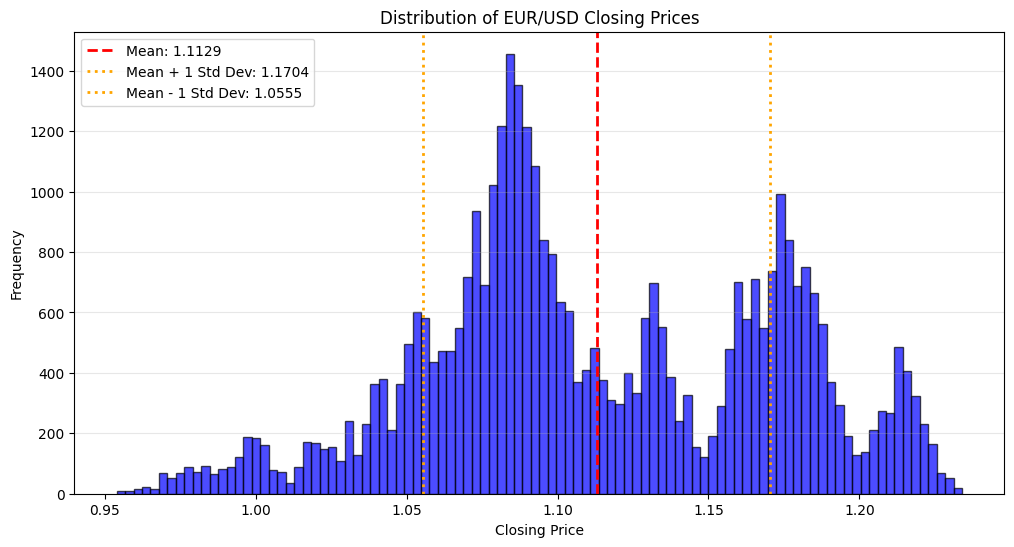

In [120]:
prices_close = df["close"]

plt.figure(figsize=(12, 6))

# plot the histogram of closing prices
plt.hist(prices_close, bins=100, color="blue", edgecolor="black", alpha=0.7)

# mean line
mu_close = prices_close.mean()
plt.axvline(mu_close, color="red", linestyle="dashed", linewidth=2, label=f"Mean: {mu_close:.4f}")

# standard deviation lines
sigma_close = prices_close.std()
plt.axvline(mu_close + sigma_close, color="orange", linestyle="dotted", linewidth=2, label=f"Mean + 1 Std Dev: {mu_close + sigma_close:.4f}")
plt.axvline(mu_close - sigma_close, color="orange", linestyle="dotted", linewidth=2, label=f"Mean - 1 Std Dev: {mu_close - sigma_close:.4f}")

# labels and title
plt.title("Distribution of EUR/USD Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

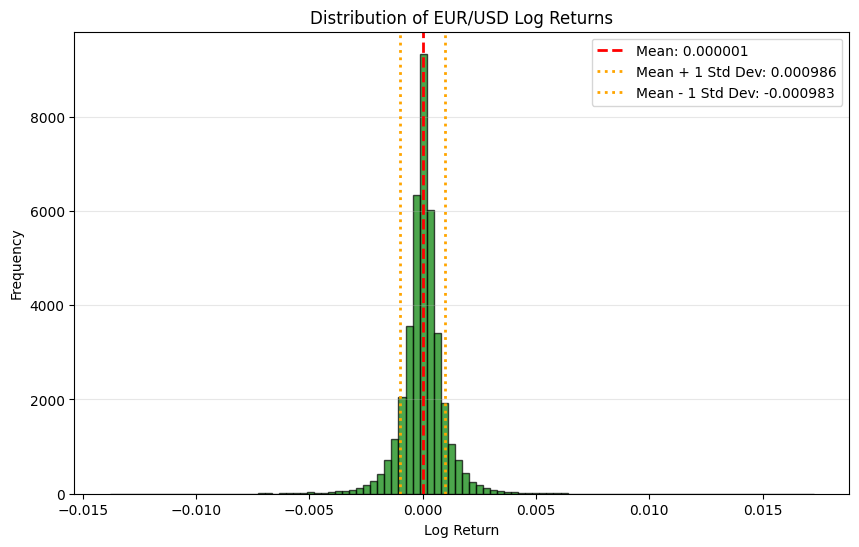

In [121]:
# calculate log returns
log_returns = (prices_close / prices_close.shift(1)).apply(np.log)

# drop the first NaN row from the shift
log_returns = log_returns.dropna()

plt.figure(figsize=(10, 6))

plt.hist(log_returns, bins=100, color="green", edgecolor="black", alpha=0.7)

# mean line
mu_log_returns = log_returns.mean()
plt.axvline(mu_log_returns, color="red", linestyle="dashed", linewidth=2, label=f"Mean: {mu_log_returns:.6f}")

# standard deviation lines
sigma_log_returns = log_returns.std()
plt.axvline(mu_log_returns + sigma_log_returns, color="orange", linestyle="dotted", linewidth=2, label=f"Mean + 1 Std Dev: {mu_log_returns + sigma_log_returns:.6f}")
plt.axvline(mu_log_returns - sigma_log_returns, color="orange", linestyle="dotted", linewidth=2, label=f"Mean - 1 Std Dev: {mu_log_returns - sigma_log_returns:.6f}")

# labels and title
plt.title("Distribution of EUR/USD Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()